# Lesson 03 — Segment and measure real pills

A real multi-pill photograph becomes labeled regions and approximate physical measurements.

## Setup

Load the MEDISEG-Deploy query photograph and its eight class annotations.

Repository: Official-Website-portfolio
Git branch: main
Lesson asset: lessons\2026-08-05\assets\03-mixed-pills.jpg
Results directory: results\lesson-03
NumPy: 2.5.1
OpenCV: 5.0.0


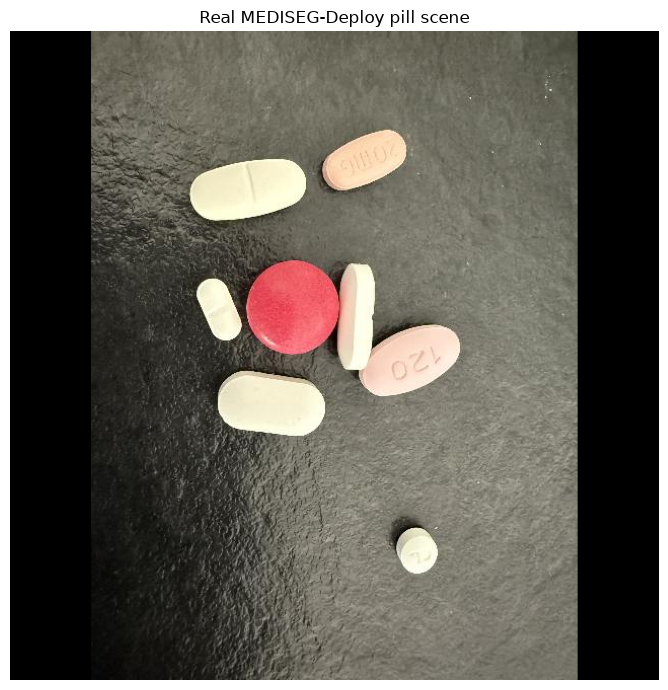

Saved: results\lesson-03\01-input.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-03/01-input.png')

In [2]:
RESULTS_NAME = "lesson-03"

from pathlib import Path
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError(
        "No Git repository root was found. Run the notebook inside the "
        "assigned repository."
    )


def find_lesson_asset(repo_root, filename):
    candidates = [
        Path.cwd() / "assets" / filename,
        repo_root
        / "program"
        / "labs"
        / "applied_computing_notebooks"
        / "03-segmentation-and-measurement"
        / "assets"
        / filename,
    ]
    lessons_root = repo_root / "lessons"
    if lessons_root.is_dir():
        candidates.extend(sorted(lessons_root.glob(f"*/assets/{filename}")))
    matches = []
    for candidate in candidates:
        if candidate.is_file() and candidate.resolve() not in matches:
            matches.append(candidate.resolve())
    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {filename} lesson asset, found {len(matches)}: {matches}"
        )
    return matches[0]


def plot_image(axis, image, title, display="gray"):
    if display == "rgb":
        axis.imshow(image)
    else:
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(output_path, dpi=150, facecolor="white")
    plt.show()
    print("Saved:", output_path.relative_to(REPO_ROOT))
    return output_path


def component_count(mask):
    return int(cv2.connectedComponents(np.asarray(mask, dtype=np.uint8))[0] - 1)


def rotated_dimensions(contour):
    (_, _), (width_px, height_px), _ = cv2.minAreaRect(contour)
    major_px, minor_px = sorted((float(width_px), float(height_px)), reverse=True)
    return major_px, minor_px


def shape_descriptors(contour):
    area_px2 = float(cv2.contourArea(contour))
    perimeter_px = float(cv2.arcLength(contour, True))
    major_px, minor_px = rotated_dimensions(contour)
    if area_px2 <= 0 or perimeter_px <= 0 or minor_px <= 0:
        raise ValueError("Contour geometry must be positive")
    return {
        "area_px2": area_px2,
        "aspect_ratio": major_px / minor_px,
        "circularity": 4.0 * np.pi * area_px2 / perimeter_px**2,
        "equivalent_diameter_px": float(np.sqrt(4.0 * area_px2 / np.pi)),
        "rotated_major_px": major_px,
        "rotated_minor_px": minor_px,
    }


def select_measurement_method(aspect_ratio, circularity):
    if aspect_ratio <= 1.20 and circularity >= 0.75:
        return "round", "equivalent_diameter"
    return "elongated", "rotated_box"


def annotation_center(annotation):
    x, y, width, height = annotation["bbox"]
    return x + width / 2.0, y + height / 2.0


def annotation_figure(image_bgr, annotations):
    annotated = image_bgr.copy()
    rows = []
    for index, annotation in enumerate(annotations, start=1):
        x, y, width, height = annotation["bbox"]
        cv2.rectangle(
            annotated,
            (x, y),
            (x + width, y + height),
            (30, 180, 255),
            2,
        )
        cv2.putText(
            annotated,
            str(index),
            (x + 4, y + 17),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (20, 20, 20),
            3,
            cv2.LINE_AA,
        )
        cv2.putText(
            annotated,
            str(index),
            (x + 4, y + 17),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        rows.append([str(index), annotation["label"]])

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(11, 7),
        gridspec_kw={"width_ratios": [1.6, 1.0]},
    )
    plot_image(
        axes[0],
        cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        "Annotated pill scene",
        display="rgb",
    )
    axes[1].axis("off")
    axes[1].set_title("MEDISEG-Deploy labels")
    table = axes[1].table(
        cellText=rows,
        colLabels=["Region", "Dataset label"],
        colLoc="left",
        cellLoc="left",
        colWidths=[0.24, 0.70],
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.55)
    return figure


def measurement_figure(image_bgr, contours, records, pixels_per_mm):
    annotated = image_bgr.copy()
    rows = []
    for index, (contour, record) in enumerate(zip(contours, records), start=1):
        color = (40, 210, 40) if record["status"] == "isolated" else (30, 165, 255)
        cv2.drawContours(annotated, [contour], -1, color, 2)
        moments = cv2.moments(contour)
        center_x = int(moments["m10"] / moments["m00"])
        center_y = int(moments["m01"] / moments["m00"])
        cv2.circle(annotated, (center_x, center_y), 12, (25, 25, 25), -1)
        cv2.putText(
            annotated,
            str(index),
            (center_x - 5, center_y + 6),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )
        names = " + ".join(record["labels"]) or "unmatched"
        size = (
            f"{record['major_mm']:.1f} x {record['minor_mm']:.1f} mm"
            if record["status"] == "isolated"
            else "merged; no individual size"
        )
        method = {
            "equivalent_diameter": "equivalent diameter",
            "rotated_box": "rotated box",
            "not_measured": "rejected",
        }[record["method"]]
        rows.append([str(index), names, record["shape_class"], method, size])

    scale_length_px = int(round(10.0 * pixels_per_mm))
    scale_start = (36, 602)
    scale_end = (scale_start[0] + scale_length_px, scale_start[1])
    cv2.line(annotated, scale_start, scale_end, (255, 255, 255), 7)
    cv2.line(annotated, scale_start, scale_end, (25, 25, 25), 3)
    cv2.putText(
        annotated,
        "10 mm estimated",
        (scale_start[0], scale_start[1] - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.44,
        (255, 255, 255),
        3,
        cv2.LINE_AA,
    )
    cv2.putText(
        annotated,
        "10 mm estimated",
        (scale_start[0], scale_start[1] - 12),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.44,
        (25, 25, 25),
        1,
        cv2.LINE_AA,
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7),
        gridspec_kw={"width_ratios": [1.05, 1.35]},
    )
    plot_image(
        axes[0],
        cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB),
        "Connected regions",
        display="rgb",
    )
    axes[1].axis("off")
    axes[1].set_title("Shape-aware physical measurements")
    table = axes[1].table(
        cellText=rows,
        colLabels=["Region", "Dataset label", "Shape", "Method", "Result"],
        colLoc="left",
        cellLoc="left",
        colWidths=[0.10, 0.34, 0.14, 0.20, 0.22],
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.55)
    return figure


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / RESULTS_NAME
if REPO_ROOT not in RESULTS_DIR.parents:
    raise RuntimeError("Results directory is outside the repository")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BRANCH = subprocess.run(
    ["git", "branch", "--show-current"],
    cwd=REPO_ROOT,
    check=True,
    capture_output=True,
    text=True,
).stdout.strip()

ASSET_PATH = find_lesson_asset(REPO_ROOT, "03-mixed-pills.jpg")
scene_bgr = cv2.imread(str(ASSET_PATH), cv2.IMREAD_COLOR)
if scene_bgr is None:
    raise RuntimeError(f"OpenCV could not read the lesson asset: {ASSET_PATH}")
if scene_bgr.shape[:2] != (640, 640):
    raise RuntimeError(f"Unexpected lesson image shape: {scene_bgr.shape}")
scene_rgb = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2RGB)
scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)
scene_hsv = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2HSV)

PILL_ANNOTATIONS = [
    {"label": "Panadol", "bbox": (177, 126, 116, 62)},
    {"label": "Esomeprazole", "bbox": (309, 97, 84, 61)},
    {"label": "Fexofenadine", "bbox": (344, 290, 100, 71)},
    {"label": "Ibuprofen", "bbox": (235, 226, 91, 94)},
    {"label": "Paracetamol 1", "bbox": (322, 230, 38, 104)},
    {"label": "Paracetamol 2", "bbox": (205, 335, 107, 65)},
    {"label": "Cetirizine", "bbox": (185, 243, 45, 64)},
    {"label": "Loperamide", "bbox": (382, 490, 40, 45)},
]
NOMINAL_MAJOR_MM = {"Panadol": 17.0, "Cetirizine": 9.4}

print("Repository:", REPO_ROOT.name)
print("Git branch:", BRANCH or "(detached)")
print("Lesson asset:", ASSET_PATH.relative_to(REPO_ROOT))
print("Results directory:", RESULTS_DIR.relative_to(REPO_ROOT))
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

figure, axis = plt.subplots(figsize=(7, 7))
plot_image(axis, scene_rgb, "Real MEDISEG-Deploy pill scene", display="rgb")
save_figure(figure, "01-input.png")

## Known pill labels

Display the dataset labels before image processing. These labels are research annotations, not clinical identification predictions.

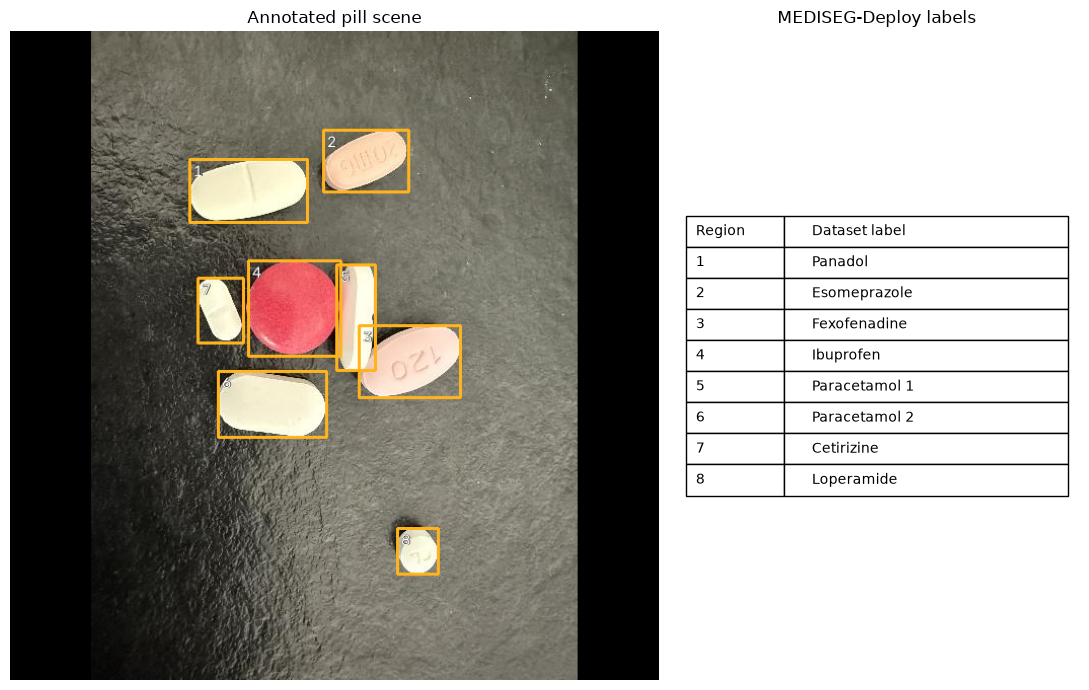

Saved: results\lesson-03\01-input-and-labels.png
Annotated pills: 8


In [3]:
figure = annotation_figure(scene_bgr, PILL_ANNOTATIONS)
save_figure(figure, "01-input-and-labels.png")
print("Annotated pills:", len(PILL_ANNOTATIONS))

## Global grayscale threshold

Predict whether the largest Otsu foreground region will contain illuminated background.

In [4]:
prediction_otsu_background_leak = "no"  # Enter "yes" or "no".
if prediction_otsu_background_leak not in {"yes", "no"}:
    raise RuntimeError('Set prediction_otsu_background_leak to "yes" or "no"')

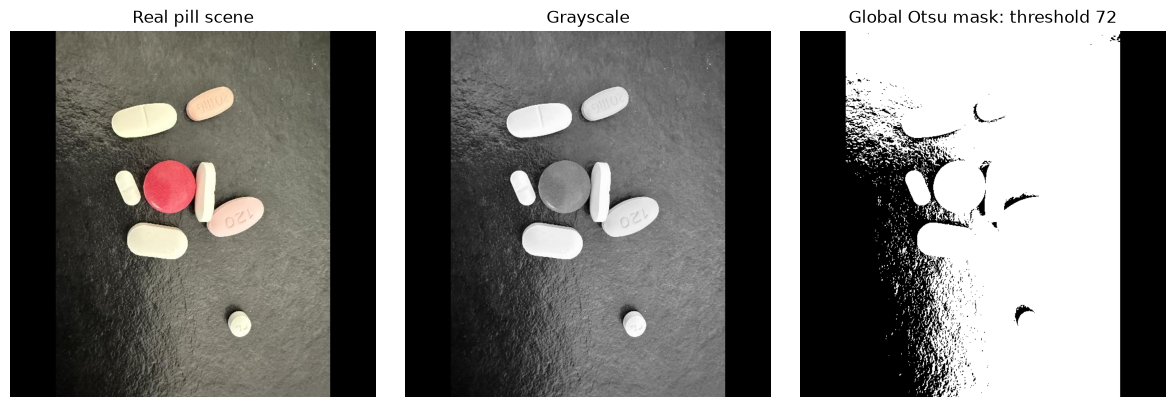

Saved: results\lesson-03\02-global-otsu-limit.png
Prediction: no
Measured background leak: True
Largest foreground component fraction: 0.566


In [5]:
def otsu_threshold(gray):
    image = np.asarray(gray, dtype=np.uint8)
    histogram = np.bincount(image.ravel(), minlength=256).astype(np.float64)
    probabilities = histogram / histogram.sum()
    cumulative_probability = np.cumsum(probabilities)
    cumulative_mean = np.cumsum(probabilities * np.arange(256))
    global_mean = cumulative_mean[-1]

    denominator = cumulative_probability * (1.0 - cumulative_probability)
    between_class_variance = np.zeros(256, dtype=np.float64)
    valid = denominator > 0
    between_class_variance[valid] = (
        global_mean * cumulative_probability[valid]
        - cumulative_mean[valid]
    ) ** 2 / denominator[valid]
    return int(np.argmax(between_class_variance))

manual_threshold = otsu_threshold(scene_gray)
opencv_threshold, otsu_mask = cv2.threshold(
    scene_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU,
)
assert manual_threshold == int(opencv_threshold)

count, _, stats, _ = cv2.connectedComponentsWithStats(otsu_mask)
largest_fraction = float(stats[1:, cv2.CC_STAT_AREA].max() / otsu_mask.size)
measured_otsu_background_leak = largest_fraction > 0.20

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_image(axes[0], scene_rgb, "Real pill scene", display="rgb")
plot_image(axes[1], scene_gray, "Grayscale")
plot_image(axes[2], otsu_mask, f"Global Otsu mask: threshold {manual_threshold}")
save_figure(figure, "02-global-otsu-limit.png")
print("Prediction:", prediction_otsu_background_leak)
print("Measured background leak:", measured_otsu_background_leak)
print("Largest foreground component fraction:", round(largest_fraction, 3))

## Color-aware candidate mask

Threshold HSV brightness so differently colored pills remain foreground.

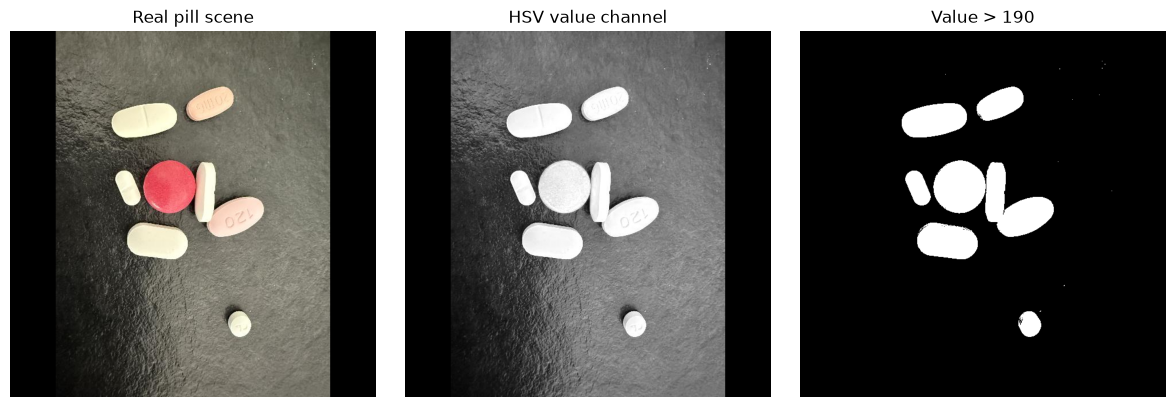

Saved: results\lesson-03\03-value-mask.png
Candidate components: 20


In [6]:
minimum_value = 190
value_channel = scene_hsv[:, :, 2]
candidate_mask = np.where(value_channel > minimum_value, 255, 0).astype(np.uint8)

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_image(axes[0], scene_rgb, "Real pill scene", display="rgb")
plot_image(axes[1], value_channel, "HSV value channel")
plot_image(axes[2], candidate_mask, f"Value > {minimum_value}")
save_figure(figure, "03-value-mask.png")
print("Candidate components:", component_count(candidate_mask))

## Morphology

Predict how opening changes the number of connected foreground components.

In [7]:
prediction_opening_components = "decrease"  # Enter "increase", "decrease", or "same".
if prediction_opening_components not in {"increase", "decrease", "same"}:
    raise RuntimeError("Set prediction_opening_components")

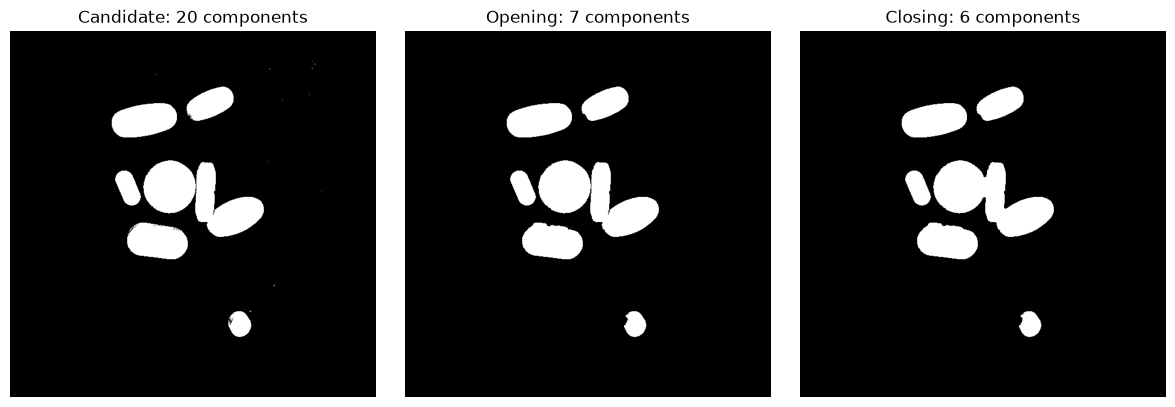

Saved: results\lesson-03\04-morphology.png
Prediction: decrease
Measured opening effect: decrease
Components: 20 7 6


In [8]:
def clean_mask(mask):
    binary = np.asarray(mask, dtype=np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return opened, closed

opened_mask, closed_mask = clean_mask(candidate_mask)
components_raw = component_count(candidate_mask)
components_opened = component_count(opened_mask)
components_closed = component_count(closed_mask)
measured_opening_effect = (
    "decrease" if components_opened < components_raw else
    "increase" if components_opened > components_raw else
    "same"
)

figure, axes = plt.subplots(1, 3, figsize=(12, 4))
plot_image(axes[0], candidate_mask, f"Candidate: {components_raw} components")
plot_image(axes[1], opened_mask, f"Opening: {components_opened} components")
plot_image(axes[2], closed_mask, f"Closing: {components_closed} components")
save_figure(figure, "04-morphology.png")
print("Prediction:", prediction_opening_components)
print("Measured opening effect:", measured_opening_effect)
print("Components:", components_raw, components_opened, components_closed)

## Connected regions

Predict whether one external contour will remain for every visible pill.

In [9]:
prediction_contour_matches_visible = "no"  # Enter "yes" or "no".
if prediction_contour_matches_visible not in {"yes", "no"}:
    raise RuntimeError('Set prediction_contour_matches_visible to "yes" or "no"')

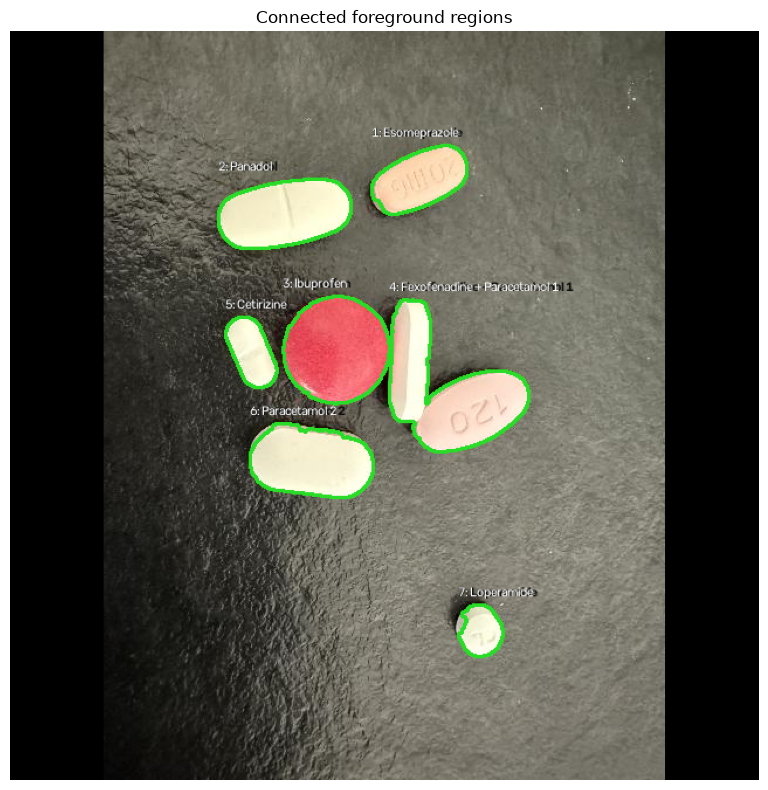

Saved: results\lesson-03\05-connected-regions.png
Prediction: no
Measured equality: False
Visible pills: 8
Connected regions: 7
Labels by region: [['Esomeprazole'], ['Panadol'], ['Ibuprofen'], ['Fexofenadine', 'Paracetamol 1'], ['Cetirizine'], ['Paracetamol 2'], ['Loperamide']]


In [10]:
def external_contours(mask, minimum_area=500):
    contours, _ = cv2.findContours(
        np.asarray(mask, dtype=np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    kept = [contour for contour in contours if cv2.contourArea(contour) >= minimum_area]
    kept.sort(key=lambda contour: cv2.boundingRect(contour)[1])
    return kept


def labels_in_contour(contour, annotations):
    labels = []
    for annotation in annotations:
        center = annotation_center(annotation)
        if cv2.pointPolygonTest(contour, center, False) >= 0:
            labels.append(annotation["label"])
    return labels

analysis_mask = opened_mask
region_contours = external_contours(analysis_mask)
region_labels = [labels_in_contour(contour, PILL_ANNOTATIONS) for contour in region_contours]
visible_pill_count = len(PILL_ANNOTATIONS)
connected_region_count = len(region_contours)
measured_contour_matches_visible = connected_region_count == visible_pill_count

contour_image = scene_bgr.copy()
for index, (contour, labels) in enumerate(zip(region_contours, region_labels), start=1):
    cv2.drawContours(contour_image, [contour], -1, (40, 220, 40), 2)
    x, y, _, _ = cv2.boundingRect(contour)
    label = f"{index}: {' + '.join(labels) if labels else 'unmatched'}"
    cv2.putText(
        contour_image,
        label,
        (x, max(16, y - 7)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        (15, 15, 15),
        3,
        cv2.LINE_AA,
    )
    cv2.putText(
        contour_image,
        label,
        (x, max(16, y - 7)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.38,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

figure, axis = plt.subplots(figsize=(8, 8))
plot_image(
    axis,
    cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB),
    "Connected foreground regions",
    display="rgb",
)
save_figure(figure, "05-connected-regions.png")
print("Prediction:", prediction_contour_matches_visible)
print("Measured equality:", measured_contour_matches_visible)
print("Visible pills:", visible_pill_count)
print("Connected regions:", connected_region_count)
print("Labels by region:", region_labels)

## Nominal-reference calibration

Use published major lengths of 17.0 mm for the matching Panadol caplet and 9.4 mm for the matching cetirizine tablet. Accept the scale only when the independent estimates agree.

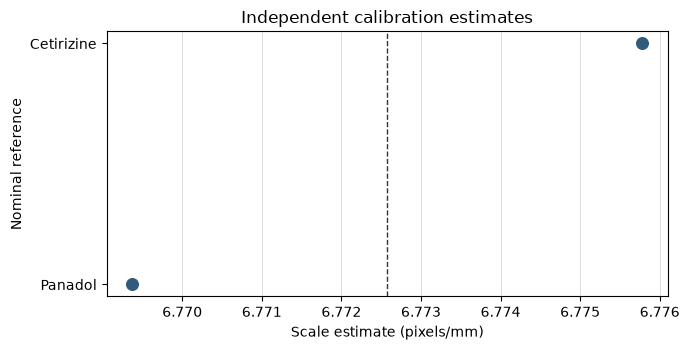

Saved: results\lesson-03\06-reference-calibration.png
Reference scales: {'Panadol': 6.7694, 'Cetirizine': 6.7758}
Consensus scale: 6.7726 pixels/mm
Relative spread: 0.095%


In [11]:
def contour_for_label(contours, annotations, label):
    annotation = next(item for item in annotations if item["label"] == label)
    center = annotation_center(annotation)
    matches = [
        contour
        for contour in contours
        if cv2.pointPolygonTest(contour, center, False) >= 0
    ]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one contour for {label}, found {len(matches)}")
    return matches[0]


def calibration_scales(contours, annotations, nominal_major_mm):
    scales = {}
    for label, major_mm in nominal_major_mm.items():
        contour = contour_for_label(contours, annotations, label)
        major_px, _ = rotated_dimensions(contour)
        scales[label] = major_px / float(major_mm)
    return scales

reference_scales = calibration_scales(
    region_contours,
    PILL_ANNOTATIONS,
    NOMINAL_MAJOR_MM,
)
pixels_per_mm = float(np.median(list(reference_scales.values())))
relative_spread = (
    max(reference_scales.values()) - min(reference_scales.values())
) / pixels_per_mm
if relative_spread > 0.02:
    raise RuntimeError(f"Reference scales disagree: {reference_scales}")

labels = list(reference_scales)
values = [reference_scales[label] for label in labels]
figure, axis = plt.subplots(figsize=(7, 3.6))
axis.scatter(values, labels, s=70, color="#315b7d")
axis.axvline(pixels_per_mm, color="#333333", linewidth=1, linestyle="--")
axis.set(
    xlabel="Scale estimate (pixels/mm)",
    ylabel="Nominal reference",
    title="Independent calibration estimates",
)
axis.grid(axis="x", color="#dddddd", linewidth=0.7)
save_figure(figure, "06-reference-calibration.png")
print("Reference scales:", {key: round(value, 4) for key, value in reference_scales.items()})
print("Consensus scale:", round(pixels_per_mm, 4), "pixels/mm")
print("Relative spread:", f"{100 * relative_spread:.3f}%")

## Shape-aware physical measurements

Calculate circularity and rotated-box aspect ratio after the shared filtering stage. Use equivalent diameter for near-circular isolated pills, rotated dimensions for elongated isolated pills, and reject multi-pill regions.

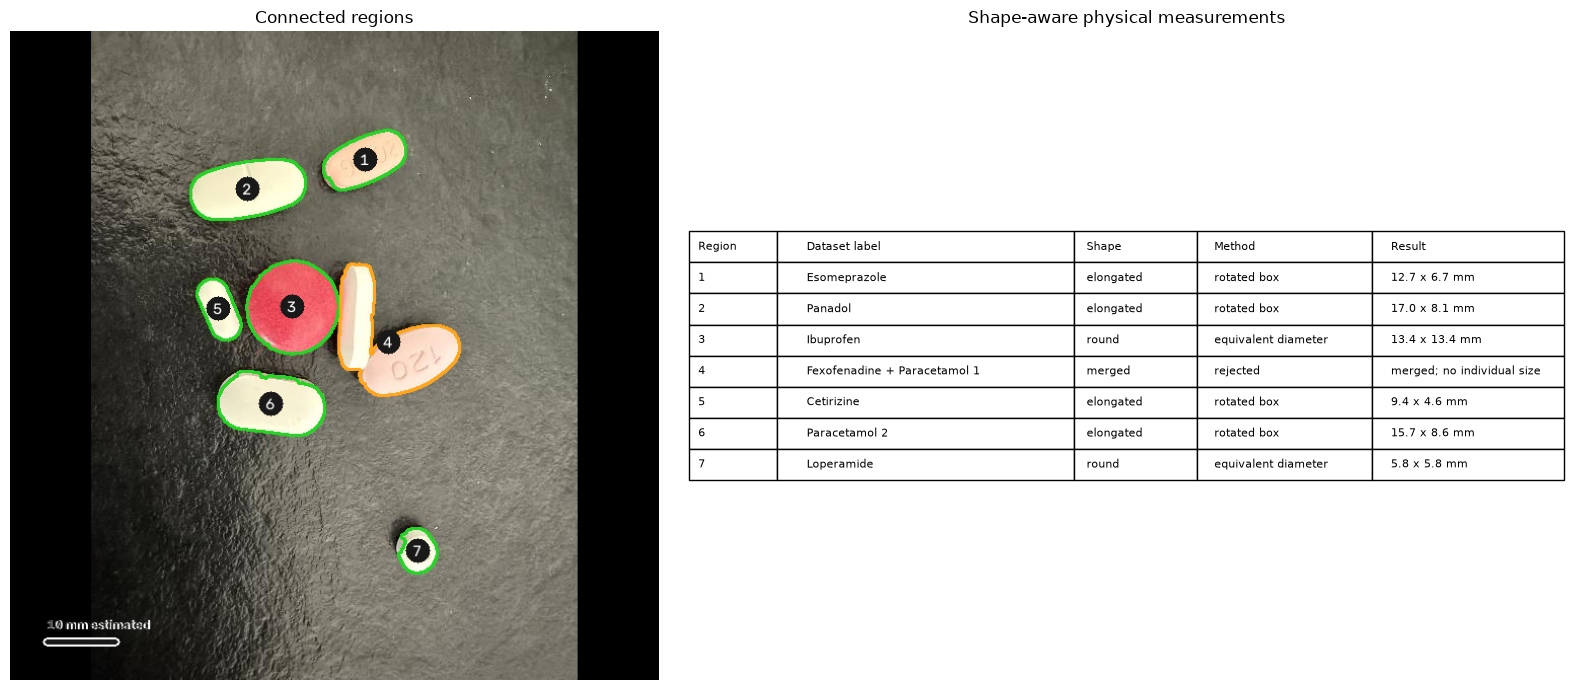

Saved: results\lesson-03\07-estimated-measurements.png
{'labels': ['Esomeprazole'], 'status': 'isolated', 'shape_class': 'elongated', 'method': 'rotated_box', 'aspect_ratio': 1.907657687197739, 'circularity': 0.7454626927981253, 'major_px': 85.99982452392578, 'minor_px': 45.08137130737305, 'major_mm': 12.698247438719124, 'minor_mm': 6.656460183573218, 'area_mm2': 69.59135994320468}
{'labels': ['Panadol'], 'status': 'isolated', 'shape_class': 'elongated', 'method': 'rotated_box', 'aspect_ratio': 2.1021021686446772, 'circularity': 0.741939039371873, 'major_px': 115.07929229736328, 'minor_px': 54.7448616027832, 'major_mm': 16.991957097052644, 'minor_mm': 8.083316477432755, 'area_mm2': 114.54668080877111}
{'labels': ['Ibuprofen'], 'status': 'isolated', 'shape_class': 'round', 'method': 'equivalent_diameter', 'aspect_ratio': 1.01039869466203, 'circularity': 0.849855388580778, 'major_px': 90.45350913296927, 'minor_px': 90.45350913296927, 'major_mm': 13.355853305855696, 'minor_mm': 13.3558533

In [12]:
def measure_regions(contours, annotations, pixels_per_mm):
    if pixels_per_mm <= 0:
        raise ValueError("pixels_per_mm must be positive")
    records = []
    for contour in contours:
        labels = labels_in_contour(contour, annotations)
        descriptors = shape_descriptors(contour)
        status = "isolated" if len(labels) == 1 else "merged"
        if status == "isolated":
            shape_class, method = select_measurement_method(
                descriptors["aspect_ratio"],
                descriptors["circularity"],
            )
            if method == "equivalent_diameter":
                major_px = descriptors["equivalent_diameter_px"]
                minor_px = major_px
            else:
                major_px = descriptors["rotated_major_px"]
                minor_px = descriptors["rotated_minor_px"]
            major_mm = major_px / pixels_per_mm
            minor_mm = minor_px / pixels_per_mm
        else:
            shape_class = "merged"
            method = "not_measured"
            major_px = None
            minor_px = None
            major_mm = None
            minor_mm = None
        records.append(
            {
                "labels": labels,
                "status": status,
                "shape_class": shape_class,
                "method": method,
                "aspect_ratio": descriptors["aspect_ratio"],
                "circularity": descriptors["circularity"],
                "major_px": major_px,
                "minor_px": minor_px,
                "major_mm": major_mm,
                "minor_mm": minor_mm,
                "area_mm2": descriptors["area_px2"] / pixels_per_mm**2,
            }
        )
    return records

measurements = measure_regions(region_contours, PILL_ANNOTATIONS, pixels_per_mm)
figure = measurement_figure(
    scene_bgr,
    region_contours,
    measurements,
    pixels_per_mm,
)
save_figure(figure, "07-estimated-measurements.png")
for record in measurements:
    print(record)

## Save measurements

Save predictions, calibration agreement, and every connected-region measurement.

In [13]:
summary_lines = [
    f"prediction_otsu_background_leak={prediction_otsu_background_leak}",
    f"measured_otsu_background_leak={measured_otsu_background_leak}",
    f"prediction_opening_components={prediction_opening_components}",
    f"measured_opening_effect={measured_opening_effect}",
    f"prediction_contour_matches_visible={prediction_contour_matches_visible}",
    f"measured_contour_matches_visible={measured_contour_matches_visible}",
    f"visible_pills={visible_pill_count}",
    f"connected_regions={connected_region_count}",
    f"pixels_per_mm={pixels_per_mm:.6f}",
    f"reference_relative_spread={relative_spread:.6f}",
]
for record in measurements:
    names = "+".join(record["labels"]) or "unmatched"
    fields = [
        f"region={names}",
        f"status={record['status']}",
        f"shape={record['shape_class']}",
        f"method={record['method']}",
        f"aspect_ratio={record['aspect_ratio']:.3f}",
        f"circularity={record['circularity']:.3f}",
    ]
    if record["status"] == "isolated":
        fields.extend([
            f"major_px={record['major_px']:.3f}",
            f"minor_px={record['minor_px']:.3f}",
            f"major_mm={record['major_mm']:.3f}",
            f"minor_mm={record['minor_mm']:.3f}",
        ])
    summary_lines.append(",".join(fields))
measurement_text = "\n".join(summary_lines) + "\n"
(RESULTS_DIR / "measurements.txt").write_text(measurement_text, encoding="utf-8")
print(measurement_text)

prediction_otsu_background_leak=no
measured_otsu_background_leak=True
prediction_opening_components=decrease
measured_opening_effect=decrease
prediction_contour_matches_visible=no
measured_contour_matches_visible=False
visible_pills=8
connected_regions=7
pixels_per_mm=6.772574
reference_relative_spread=0.000946
region=Esomeprazole,status=isolated,shape=elongated,method=rotated_box,aspect_ratio=1.908,circularity=0.745,major_px=86.000,minor_px=45.081,major_mm=12.698,minor_mm=6.656
region=Panadol,status=isolated,shape=elongated,method=rotated_box,aspect_ratio=2.102,circularity=0.742,major_px=115.079,minor_px=54.745,major_mm=16.992,minor_mm=8.083
region=Ibuprofen,status=isolated,shape=round,method=equivalent_diameter,aspect_ratio=1.010,circularity=0.850,major_px=90.454,minor_px=90.454,major_mm=13.356,minor_mm=13.356
region=Fexofenadine+Paracetamol 1,status=merged,shape=merged,method=not_measured,aspect_ratio=1.460,circularity=0.397
region=Cetirizine,status=isolated,shape=elongated,method=r

## Questions

1. Why did grayscale Otsu leak into the background? The Otsu algorithm couldn't differentiate the background from the pixels because there were bright spots that matched the brightness of the pills-this led to a leakage that formed a massive blob in post-processing. THis is clear from the dark spot that was left dark in post-processing and was also dark in the unprocessed image in the bottom left corner.
2. Why did opening preserve more pill separation than closing? Opening erodes then dilates-removing noise in the erode phase and only growing what survived in the dilate phase. Closing did the opposite-it dilated first-this led to the amplification of the gaps beteen pill (even if noise was amplified in the dilation phase, in the erode phase that came later, the noise was lessened). The erode phase in the closing procedure failed to remove the exaggerated gaps-this merged pils together.
3. Why do two agreeing nominal references strengthen the calibration? One nominal reference makes you guess-you wouldn't know if it is wrong or right since you can't compare it to anything. Two nominal references fix this issue-by having two references, we can compare spread to check precision and will know if something went wrong because of discrepancies.
4. Why can all pill shapes share one segmentation filter? The segmentation filter checks pixel identity using a brightness threshold-it doesn't care what kind of pill the pixel belongs to-only if it is within a threshold. 
5. Why must a merged region be separated before individual measurement?A merged region blends multiple objects-in this case pills-which doesn't
6. 5. Why must a merged region be separated before individual measurement? A merged blob contains multiple pills touching, so measuring the combined blob gives dimensions that match neither pill-it is just the sum of two objects. You must separate merged regions first to get individual measurements for each pill.

Commit the executed notebook and `results/lesson-03/`, then push.

Sources: [MEDISEG dataset](https://city.figshare.com/articles/dataset/MEDISEG/28574786) · [OpenCV thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html) · [OpenCV morphology](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html) · [Panadol nominal length](https://dailymed.nlm.nih.gov/dailymed/getFile.cfm?name=PANADOL+EXTRA+STRENGTH&setid=b2fe7f47-1a2e-40ee-8f8f-38f2028dce1b) · [Cetirizine nominal dimensions](https://www.medicines.org.uk/emc/product/12956/smpc)